In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.datasets import make_blobs
from sklearn.ensemble import IsolationForest

# 根据分位数找异常值

In [25]:
np.random.seed(42) 
x = np.random.randn(1000, 1) 
# 生成100个服从标准正态分布的数, 构成一个二维ndarray
print(x)
print(x.shape)

[[ 4.96714153e-01]
 [-1.38264301e-01]
 [ 6.47688538e-01]
 [ 1.52302986e+00]
 [-2.34153375e-01]
 [-2.34136957e-01]
 [ 1.57921282e+00]
 [ 7.67434729e-01]
 [-4.69474386e-01]
 [ 5.42560044e-01]
 [-4.63417693e-01]
 [-4.65729754e-01]
 [ 2.41962272e-01]
 [-1.91328024e+00]
 [-1.72491783e+00]
 [-5.62287529e-01]
 [-1.01283112e+00]
 [ 3.14247333e-01]
 [-9.08024076e-01]
 [-1.41230370e+00]
 [ 1.46564877e+00]
 [-2.25776300e-01]
 [ 6.75282047e-02]
 [-1.42474819e+00]
 [-5.44382725e-01]
 [ 1.10922590e-01]
 [-1.15099358e+00]
 [ 3.75698018e-01]
 [-6.00638690e-01]
 [-2.91693750e-01]
 [-6.01706612e-01]
 [ 1.85227818e+00]
 [-1.34972247e-02]
 [-1.05771093e+00]
 [ 8.22544912e-01]
 [-1.22084365e+00]
 [ 2.08863595e-01]
 [-1.95967012e+00]
 [-1.32818605e+00]
 [ 1.96861236e-01]
 [ 7.38466580e-01]
 [ 1.71368281e-01]
 [-1.15648282e-01]
 [-3.01103696e-01]
 [-1.47852199e+00]
 [-7.19844208e-01]
 [-4.60638771e-01]
 [ 1.05712223e+00]
 [ 3.43618290e-01]
 [-1.76304016e+00]
 [ 3.24083969e-01]
 [-3.85082280e-01]
 [-6.7692200

In [26]:
# 随机一个dataframe作为模拟数据集, 检测列column_name的异常值
df=pd.DataFrame(x,columns=['column_name'])
Q1 = df['column_name'].quantile(0.25)  
# 第一四分位数（25%）
Q3 = df['column_name'].quantile(0.75)  
# 第三四分位数（75%）
print(Q1,Q3)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print(lower_bound,upper_bound)
# 在1.5*IQR之外的点被称为异常值或离群点

df['outlier'] = df['column_name'].apply(lambda y: 'Yes' 
if y < lower_bound or y > upper_bound
else 'No')

# 打印出被标记为异常值的行
print(df[df['outlier'] == 'Yes'])

-0.6475903054623516 0.6479438754729301
-2.5908915768652743 2.5912451468758526
     column_name outlier
74     -2.619745     Yes
179     2.720169     Yes
209     3.852731     Yes
262    -3.241267     Yes
478     3.078881     Yes
646    -2.696887     Yes
668    -2.650970     Yes
755     2.632382     Yes


# 使用Z-score检测异常值

In [27]:
mean = df['column_name'].mean()
std = df['column_name'].std()
print(mean,std)
df['z_score'] = (df['column_name'] - mean) / std
# 设定阈值|Z|> 3
df['outlier'] = df['z_score'].apply(lambda z: 'Yes' if abs(z) > 3 else 'No')
# 视距离均值三个标准差之外的点为异常值
outliers = df[df['outlier'] == 'Yes']
print(outliers)

0.01933205582232549 0.9792159381796757
     column_name outlier   z_score
209     3.852731     Yes  3.914764
262    -3.241267     Yes -3.329806
478     3.078881     Yes  3.124488


# DBSCAN算法

(1500, 2)
(1600, 2)


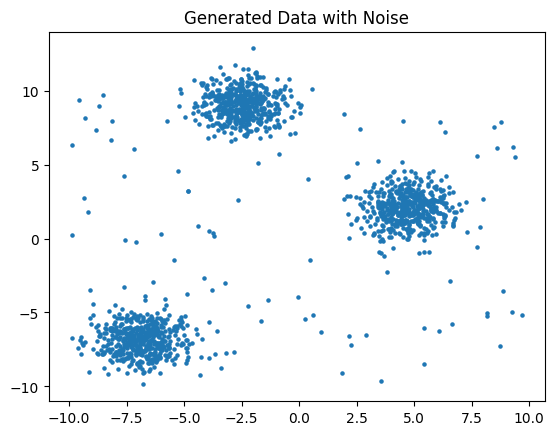

In [32]:
x, y = make_blobs(n_samples=1500, random_state=42)
# 生成聚类测试样例
# 在横纵坐标[-10, 10]的范围内选几个点(默认三个)作为簇中心, 以高斯分布随机生成1500个点
# x是特征矩阵, y是簇标签(这里没用)
print(x.shape)
rng = np.random.RandomState(42)
x = np.concatenate([x, rng.uniform(low=-10, high=10, size=(100, 2))])
# 在横纵坐标[-10, 10]的方框内生成100个均匀分布的噪声点
print(x.shape)
plt.scatter(x[:, 0], x[:, 1], s=5)
# 以数据的0列为横坐标, 1列为纵坐标, 绘制散点图
plt.title("Generated Data with Noise")
plt.show()

[-1  0  1  2]
[False False False False False]
75
[0 1 2]


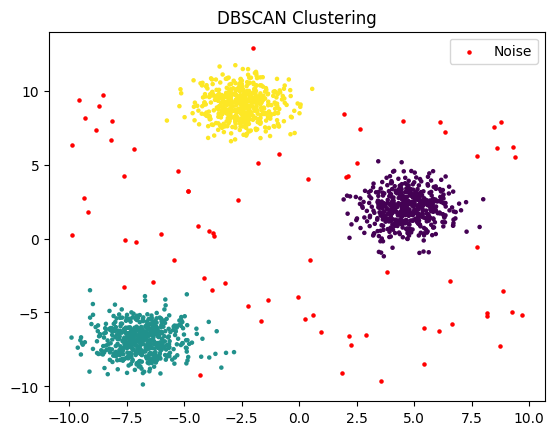

In [36]:
# 使用DBSCAN算法
db = DBSCAN(eps=1.0, min_samples=5).fit(x) 
# eps是半径
# min_samples最少包含几个点才会被认为是核心点
labels = db.labels_ 
print(np.unique(labels)) 
# 得到类别有-1 0 1 2 总计4个类别, 3簇
noise_mask = (labels == -1)
# 标签为-1的点是噪声点. 设置一个布尔索引, 对应位置为True则是噪声点
print(noise_mask[0:5])
print(np.sum(noise_mask)) 
# 噪声点的数量
print(np.unique(labels[~noise_mask])) 
# 对布尔数组取反得到非噪声点
# 核心点和边界点的标签为0 1 2
plt.scatter(x[~noise_mask, 0], x[~noise_mask, 1], c=labels[~noise_mask],
            s=5, cmap='viridis') 
# 正常点(包含核心点和边界点)用彩色标注
plt.scatter(x[noise_mask, 0], x[noise_mask, 1], c='red', s=5, label='Noise')
# 噪声点用红色标注
plt.title("DBSCAN Clustering")
plt.legend()
plt.show()

# 孤立森林

[-0.16687143 -0.14722083 -0.123284   -0.12108449 -0.11883265]
[978 580 795 550 769]
[[-2.13567421  3.13774853]
 [-2.49940571  2.29094257]
 [-1.07213901 -2.92135048]
 [ 0.99801011 -2.89625538]
 [-1.16991684 -2.87226221]]
[-1  1]


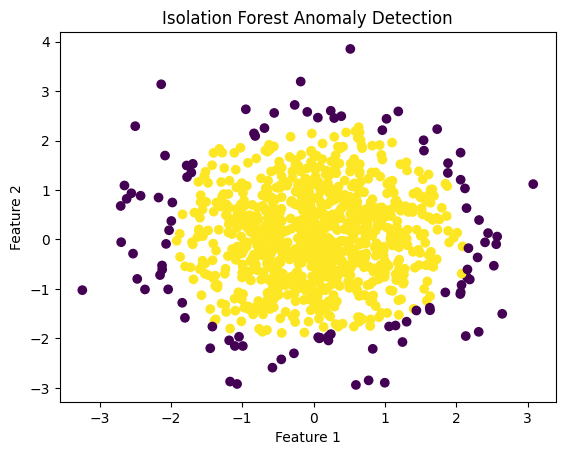

In [44]:
np.random.seed(42)
x = np.random.randn(1000, 2)

# 初始化Isolation Forest模型
# contamination参数表示异常值比例，默认0.1
# random_state参数表示随机种子, 用来设置随机分割点
iso_forest = IsolationForest(random_state=42, contamination=0.1)
# 随机选择特征, 选择随机的值进行分裂, 对每个子节点进行同样的操作直到叶子只有一个点
# n_estimators表示树的数量, 默认为100
iso_forest.fit(x)

scores = iso_forest.decision_function(x)
# 将一个点在所有树深度的平均值进行归一化后和中心化就是异常分数 
outlier_index = np.argsort(scores)[:5]
# argsort()返回的是按照参数升序排序后的索引
print(scores[outlier_index])
print(outlier_index)
print(x[outlier_index])
# 输出最异常的的五个点
labels = iso_forest.predict(x)
# 将scores转换成1（正常）和-1（异常)的异常标签
print(np.unique(labels))
plt.scatter(x[:, 0], x[:, 1], c=labels)
plt.title('Isolation Forest Anomaly Detection')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()